# Model Selection And Untouched Test

Compares statistical and ML candidates using rolling origins, then evaluates the locked selection champion on a separate final window.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = Path("Ai miroservices/modeling/project_operational_baseline").resolve()
OUT = ROOT / "outputs"
EVAL = OUT / "evaluator"
sns.set_theme(style="whitegrid")

In [2]:
leaderboard=pd.read_csv(OUT/'model_leaderboard.csv')
summary=json.loads((OUT/'forecast_evidence_summary.json').read_text())
display(leaderboard)
summary

,split,model_name,rows,materials,WAPE,MAE,RMSE,Bias,under_forecast_rate,selection_score
0,selection,EXTRA_TREES_RESPONSIVE,3456,96,0.117171,120.034606,304.444758,0.049767,0.572627,0.142054
1,selection,EXTRA_TREES,3456,96,0.118336,121.228635,310.398207,0.055722,0.576678,0.146197
2,selection,EXTRA_TREES_DAMPED_TREND,3456,96,0.131142,134.347259,330.520419,0.041685,0.548322,0.151984
3,selection,LIGHTGBM,3456,96,0.130095,133.274665,339.841440,0.064659,0.611111,0.162424
4,selection,MOVING_AVERAGE_3,3456,96,0.164500,168.521229,397.932598,0.048074,0.592303,0.188538
5,selection,SEASONAL_NAIVE,3456,96,0.170096,174.254036,474.831923,0.082614,0.631655,0.211403
6,selection,ETS_A_N_A,3456,96,0.168110,172.219521,419.897833,0.110397,0.678819,0.223309
7,selection,CROSTON_SBA,3456,96,0.229535,235.145831,540.739028,0.203491,0.804109,0.331281
8,untouched_test,EXTRA_TREES,1152,96,0.126503,127.697426,479.432245,-0.019416,0.481771,0.136211
9,untouched_test,EXTRA_TREES_RESPONSIVE,1152,96,0.127608,128.812941,488.244632,-0.017366,0.484375,0.136291


{'champion': 'EXTRA_TREES_RESPONSIVE',
 'selection_window': ['2023-01-01', '2024-12-01'],
 'selection_origins': ['2023-01-01', '2023-07-01', '2024-01-01'],
 'untouched_test_window': ['2025-01-01', '2025-12-01'],
 'evaluation_protocol': 'expanding-window fixed-origin recursive H1-H12; final 12 months untouched',
 'selection_objective': 'WAPE + 0.5 * absolute bias, computed on selection origins only',
 'forecast_scope': {'packaging_material': 32,
  'product': 16,
  'raw_material': 48},
 'test_metrics': {'rows': 1152,
  'materials': 96,
  'WAPE': 0.1276078980742894,
  'MAE': 128.81294077329278,
  'RMSE': 488.24463165897646,
  'Bias': -0.017366087822577852,
  'under_forecast_rate': 0.484375},
 'seasonal_naive_test_wape': 0.17433061456110985,
 'relative_wape_improvement': 0.26801211367520456,
 'interval_nominal_coverage': 0.9,
 'interval_empirical_coverage': 0.8914930555555556,
 'critical_class_wape': 0.11394883254547364,
 'interval_calibration_method': 'signed residual 5th/95th quantiles f

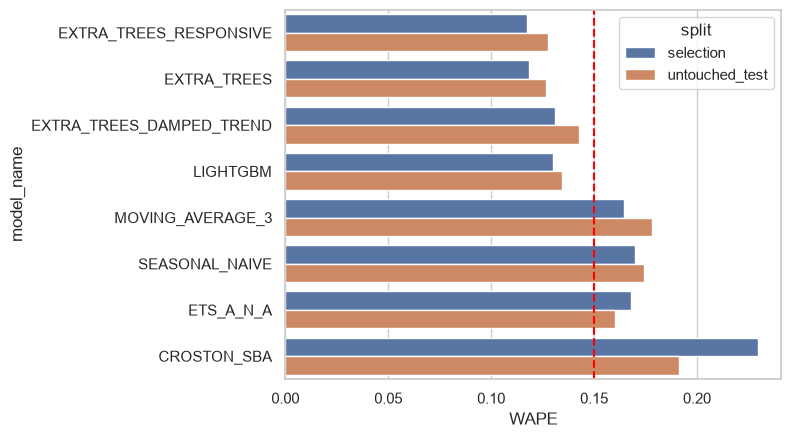

In [3]:
sns.barplot(data=leaderboard,x='WAPE',y='model_name',hue='split'); plt.axvline(.15,color='red',ls='--'); plt.show()

In [4]:
paired=pd.read_csv(OUT/'paired_model_tests.csv')
display(paired)
print('Champion was selected only from the selection split:', summary['champion'])

,champion,challenger,test,statistic,p_value
0,EXTRA_TREES_RESPONSIVE,EXTRA_TREES,Wilcoxon paired absolute error,2930130.0,3.336217e-01
1,EXTRA_TREES_RESPONSIVE,EXTRA_TREES_DAMPED_TREND,Wilcoxon paired absolute error,2575259.0,2.280473e-12
2,EXTRA_TREES_RESPONSIVE,LIGHTGBM,Wilcoxon paired absolute error,2613853.0,2.040419e-10
3,EXTRA_TREES_RESPONSIVE,MOVING_AVERAGE_3,Wilcoxon paired absolute error,2018206.0,3.008622e-61
4,EXTRA_TREES_RESPONSIVE,SEASONAL_NAIVE,Wilcoxon paired absolute error,1912438.0,6.288025e-75
5,EXTRA_TREES_RESPONSIVE,ETS_A_N_A,Wilcoxon paired absolute error,1907449.0,1.313674e-75
6,EXTRA_TREES_RESPONSIVE,CROSTON_SBA,Wilcoxon paired absolute error,1263491.0,1.072730e-189


Champion was selected only from the selection split: EXTRA_TREES_RESPONSIVE


In [5]:
evaluator=json.loads((EVAL/'evaluator_run_summary.json').read_text())
evaluator_board=pd.read_csv(EVAL/'model_leaderboard.csv')
hypothesis=pd.read_csv(EVAL/'model_hypothesis_tests.csv')
display(evaluator_board[evaluator_board.population.eq('RM_PM_PRIMARY')])
display(evaluator_board[evaluator_board.population.eq('FG_SECONDARY')])
display(hypothesis)
evaluator

,split,model_name,rows,series,WAPE,MAE,RMSE,Bias,under_forecast_rate,selection_score,population
0,selection,EXTRA_TREES,6720,80,0.113939,114.944145,327.297109,0.062578,0.604464,0.145228,RM_PM_PRIMARY
1,selection,EXTRA_TREES_RESPONSIVE,6720,80,0.114480,115.490491,328.577803,0.062036,0.597470,0.145499,RM_PM_PRIMARY
2,selection,EXTRA_TREES_DAMPED_TREND,6720,80,0.122147,123.225023,339.762468,0.053979,0.580208,0.149137,RM_PM_PRIMARY
3,selection,LIGHTGBM,6720,80,0.133896,135.077243,383.688106,0.072586,0.621429,0.170189,RM_PM_PRIMARY
4,selection,MOVING_AVERAGE_3,6720,80,0.134775,135.964453,347.657794,0.072731,0.648661,0.171141,RM_PM_PRIMARY
5,selection,SEASONAL_NAIVE,6720,80,0.154340,155.701885,492.002956,0.074809,0.634673,0.191745,RM_PM_PRIMARY
6,selection,ETS_A_N_A,6720,80,0.153676,155.031519,417.985413,0.105691,0.697470,0.206521,RM_PM_PRIMARY
7,selection,CONV1D_ATTENTION_GLOBAL,6720,80,0.261239,263.543480,919.111316,0.098127,0.610268,0.310302,RM_PM_PRIMARY
8,selection,CROSTON_SBA,6720,80,0.224421,226.400483,559.810093,0.204550,0.816964,0.326695,RM_PM_PRIMARY
27,untouched_test,EXTRA_TREES,960,80,0.125254,121.320571,515.922895,-0.027837,0.480208,0.139172,RM_PM_PRIMARY


,split,model_name,rows,series,WAPE,MAE,RMSE,Bias,under_forecast_rate,selection_score,population
9,selection,EXTRA_TREES_RESPONSIVE,1344,16,0.129623,158.320032,236.446860,0.058886,0.580357,0.159066,FG_SECONDARY
10,selection,EXTRA_TREES,1344,16,0.130356,159.214703,236.148733,0.058384,0.578869,0.159547,FG_SECONDARY
11,selection,LIGHTGBM,1344,16,0.135925,166.016969,248.738453,0.054738,0.618304,0.163294,FG_SECONDARY
12,selection,EXTRA_TREES_DAMPED_TREND,1344,16,0.149710,182.854216,260.799165,0.049116,0.554315,0.174268,FG_SECONDARY
13,selection,ETS_A_N_A,1344,16,0.196789,240.356164,353.598304,0.096581,0.659226,0.245080,FG_SECONDARY
14,selection,SEASONAL_NAIVE,1344,16,0.212573,259.633896,377.322238,0.066016,0.628720,0.245581,FG_SECONDARY
15,selection,MOVING_AVERAGE_3,1344,16,0.214274,261.711319,359.094797,0.085665,0.642857,0.257106,FG_SECONDARY
16,selection,CONV1D_ATTENTION_GLOBAL,1344,16,0.218936,267.405491,386.247641,0.091013,0.633185,0.264442,FG_SECONDARY
17,selection,CROSTON_SBA,1344,16,0.245003,299.243387,406.997800,0.199883,0.804315,0.344944,FG_SECONDARY
36,untouched_test,EXTRA_TREES,192,16,0.126623,153.677556,251.063578,0.008098,0.489583,0.130672,FG_SECONDARY


,champion,challenger,paired_rows,mean_absolute_error_difference,relative_WAPE_difference,dm_hac_statistic,dm_hac_p_value,block_bootstrap_ci_low,block_bootstrap_ci_high,test_note,holm_p_value,statistically_distinguishable
0,EXTRA_TREES,CONV1D_ATTENTION_GLOBAL,6720,-148.599336,-0.147300,-10.763595,5.113572e-27,-234.940861,-72.413610,HAC lag accounts for overlapping H1-H12 foreca...,3.068143e-26,True
1,EXTRA_TREES,CROSTON_SBA,6720,-111.456338,-0.110482,-30.947545,2.741402e-210,-146.918171,-76.131445,HAC lag accounts for overlapping H1-H12 foreca...,2.193121e-209,True
2,EXTRA_TREES,SEASONAL_NAIVE,6720,-40.757740,-0.040401,-10.507295,7.995386e-26,-54.218690,-26.250327,HAC lag accounts for overlapping H1-H12 foreca...,3.198155e-25,True
3,EXTRA_TREES,ETS_A_N_A,6720,-40.087375,-0.039737,-23.834853,1.454026e-125,-54.972936,-23.347485,HAC lag accounts for overlapping H1-H12 foreca...,1.017818e-124,True
4,EXTRA_TREES,MOVING_AVERAGE_3,6720,-21.020308,-0.020836,-10.093858,5.881164e-24,-39.882035,-5.327534,HAC lag accounts for overlapping H1-H12 foreca...,1.764349e-23,True
5,EXTRA_TREES,LIGHTGBM,6720,-20.133098,-0.019957,-10.608944,2.707910e-26,-30.984907,-8.997092,HAC lag accounts for overlapping H1-H12 foreca...,1.353955e-25,True
6,EXTRA_TREES,EXTRA_TREES_DAMPED_TREND,6720,-8.280878,-0.008208,-5.571119,2.531089e-08,-14.050898,-1.917375,HAC lag accounts for overlapping H1-H12 foreca...,5.062177e-08,True
7,EXTRA_TREES,EXTRA_TREES_RESPONSIVE,6720,-0.546347,-0.000542,-0.420389,6.742014e-01,-4.598859,3.060378,HAC lag accounts for overlapping H1-H12 foreca...,6.742014e-01,False


{'data_tier': 'GENERATED_OPERATIONAL_BASELINE',
 'history_months': 24,
 'forecast_horizon_months': 12,
 'series_total': 96,
 'rm_pm_series': 80,
 'finished_good_series': 16,
 'selection_origins': ['2023-07-01',
  '2023-08-01',
  '2023-09-01',
  '2023-10-01',
  '2023-11-01',
  '2023-12-01',
  '2024-01-01'],
 'untouched_test_window': ['2025-01-01', '2025-12-01'],
 'neural_seeds': [17, 42, 101, 303, 707],
 'baseline_champion': 'EXTRA_TREES',
 'locked_champion': 'EXTRA_TREES',
 'neural_promoted': False,
 'promotion_reason': 'Neural challenger did not rank first on locked pre-test selection score.',
 'neural_selection_coverage_p10_p90': 0.7790178571428571,
 'neural_selection_calibration_gate': True,
 'neural_selection_decision_cost_gate': False,
 'test_metrics': {'split': 'untouched_test',
  'model_name': 'EXTRA_TREES',
  'rows': 960,
  'series': 80,
  'WAPE': 0.12525363164573086,
  'MAE': 121.32057119285304,
  'RMSE': 515.9228945091266,
  'Bias': -0.027837205358380836,
  'under_forecast_ra